In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder

In [5]:
iris=load_iris()
df=pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"]=iris.target

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df=df[df["Species"]!=0][["sepal width (cm)", "petal length (cm)", "Species"]]

In [8]:
df.head()

,sepal width (cm),petal length (cm),Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


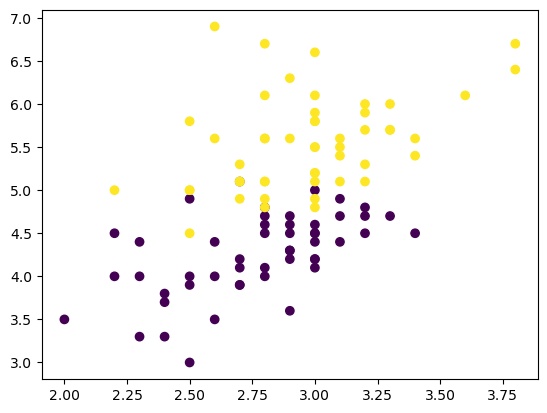

In [10]:
import matplotlib.pyplot as plt
plt.scatter(df['sepal width (cm)'], df['petal length (cm)'], c=df['Species'])

In [ ]:
df=df.sample(100) # TO SHUFFLE THE ROWS 1'S AND 2'S

In [12]:
df.head()

,sepal width (cm),petal length (cm),Species
73,2.8,4.7,1
121,2.8,4.9,2
85,3.4,4.5,1
98,2.5,3.0,1
71,2.8,4.0,1


In [14]:
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)


In [15]:
df_train

,sepal width (cm),petal length (cm),Species
52,3.1,4.9,1
95,3.0,4.2,1
110,3.2,5.1,2
124,3.3,5.7,2
91,3.0,4.6,1
117,3.8,6.7,2
140,3.1,5.6,2
132,2.8,5.6,2
82,2.7,3.9,1
130,2.8,6.1,2


In [16]:
df_val

,sepal width (cm),petal length (cm),Species
58,2.9,4.6,1
116,3.0,5.5,2
137,3.1,5.5,2
119,2.2,5.0,2
145,3.0,5.2,2


In [17]:
df_test

,sepal width (cm),petal length (cm),Species
111,2.7,5.3,2
74,2.9,4.3,1
83,2.7,5.1,1
112,3.0,5.5,2
144,3.3,5.7,2


In [18]:
X_test=df_val.iloc[:,0:2].values
y_test=df_val.iloc[:,2].values

## Case 1

In [28]:
df_bag=df_train.sample(8,replace=True)

X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,2]

df_bag

,sepal width (cm),petal length (cm),Species
95,3.0,4.2,1
110,3.2,5.1,2
91,3.0,4.6,1
52,3.1,4.9,1
117,3.8,6.7,2
91,3.0,4.6,1
52,3.1,4.9,1
124,3.3,5.7,2


In [29]:
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

In [30]:
dt_bag1=DecisionTreeClassifier()

In [31]:
def evaluate(clf, X, y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred=clf.predict(X_test)
    print("Accuracy Score: ",accuracy_score(y_test, y_pred) )

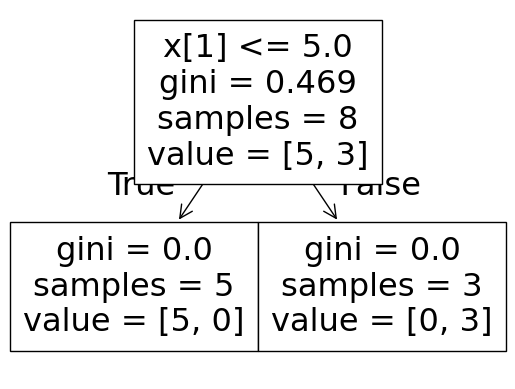

c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy Score:  0.8


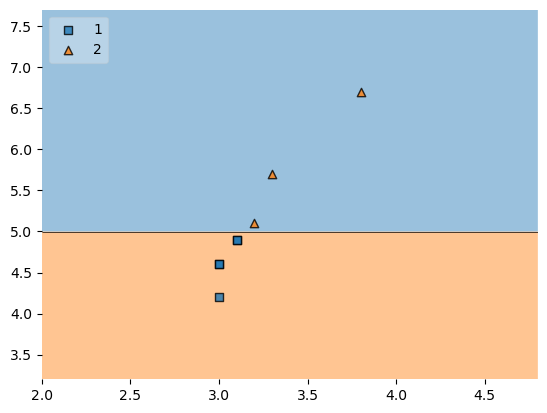

In [32]:
evaluate(dt_bag1, X, y)

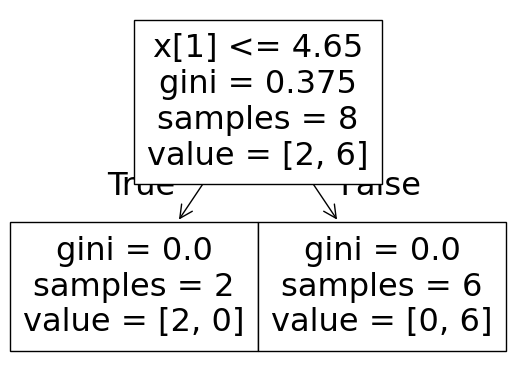

c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy Score:  1.0


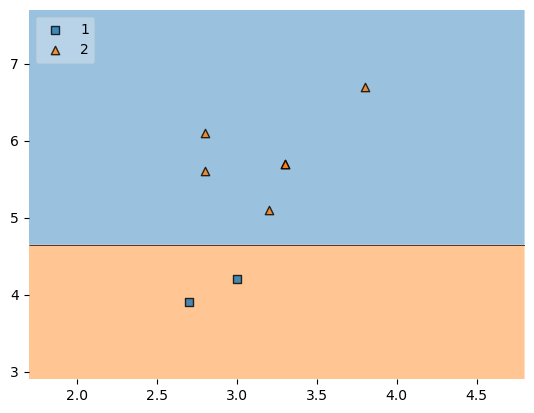

In [33]:
df_bag=df_train.sample(8,replace=True)

X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,2]

df_bag
dt_bag2=DecisionTreeClassifier()
evaluate(dt_bag2, X, y)

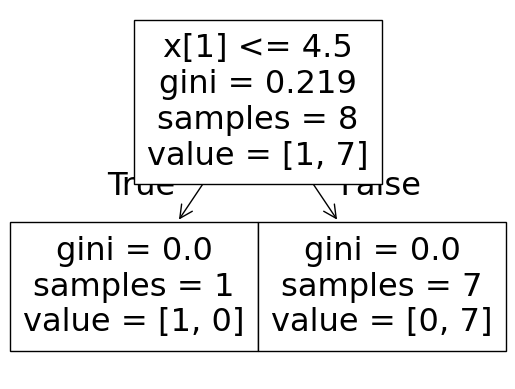

c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy Score:  0.8


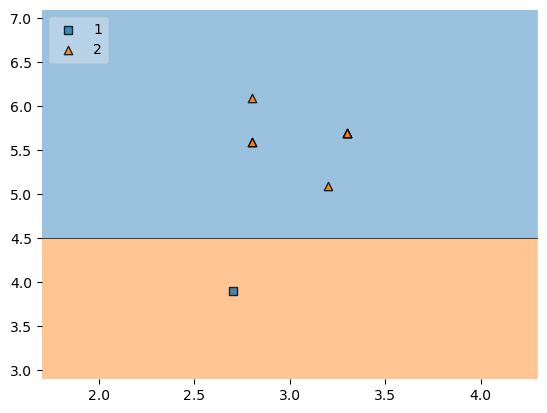

In [36]:
df_bag=df_train.sample(8,replace=True)

X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,2]

df_bag
dt_bag3=DecisionTreeClassifier()
evaluate(dt_bag3, X, y)

### checking the predection using the DF_test

In [35]:
df_test

,sepal width (cm),petal length (cm),Species
111,2.7,5.3,2
74,2.9,4.3,1
83,2.7,5.1,1
112,3.0,5.5,2
144,3.3,5.7,2


In [37]:
print("Predictor1", dt_bag1.predict(np.array([2.7, 5.3]).reshape(1,2)))
print("Predictor2", dt_bag2.predict(np.array([2.7, 5.3]).reshape(1,2)))
print("Predictor3", dt_bag3.predict(np.array([2.7, 5.3]).reshape(1,2)))



Predictor1 [2]
Predictor2 [2]
Predictor3 [2]


c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Pasting 
**row sampling without replacement** 

In [38]:
df_train

,sepal width (cm),petal length (cm),Species
52,3.1,4.9,1
95,3.0,4.2,1
110,3.2,5.1,2
124,3.3,5.7,2
91,3.0,4.6,1
117,3.8,6.7,2
140,3.1,5.6,2
132,2.8,5.6,2
82,2.7,3.9,1
130,2.8,6.1,2


In [39]:
df_train.sample(8)

,sepal width (cm),petal length (cm),Species
91,3.0,4.6,1
124,3.3,5.7,2
110,3.2,5.1,2
117,3.8,6.7,2
52,3.1,4.9,1
82,2.7,3.9,1
95,3.0,4.2,1
140,3.1,5.6,2


### Random Subspaces
**we do column sampling instead of row sampling with/without replacement**

In [41]:
df1=pd.DataFrame(iris.data, columns=iris.feature_names)
df1['Species']=iris.target

In [42]:
df1.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [43]:
df1=df1.sample(10)

In [44]:
df1.sample(2,replace=True, axis=1) 

,petal width (cm),Species
52,1.5,1
98,1.1,1
62,1.0,1
27,0.2,0
82,1.2,1
47,0.2,0
58,1.3,1
59,1.4,1
46,0.2,0
66,1.5,1


In [45]:
df1.sample(2,replace=True, axis=1) 


,sepal width (cm),petal width (cm)
52,3.1,1.5
98,2.5,1.1
62,2.2,1.0
27,3.5,0.2
82,2.7,1.2
47,3.2,0.2
58,2.9,1.3
59,2.7,1.4
46,3.8,0.2
66,3.0,1.5


## Random Patches 
**we do row sampling and column sampling** 

In [46]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
52,6.9,3.1,4.9,1.5,1
98,5.1,2.5,3.0,1.1,1
62,6.0,2.2,4.0,1.0,1
27,5.2,3.5,1.5,0.2,0
82,5.8,2.7,3.9,1.2,1
47,4.6,3.2,1.4,0.2,0
58,6.6,2.9,4.6,1.3,1
59,5.2,2.7,3.9,1.4,1
46,5.1,3.8,1.6,0.2,0
66,5.6,3.0,4.5,1.5,1


In [47]:
df1.sample(8, replace=True).sample(2,replace=True,axis=1)

,sepal width (cm),sepal width (cm)
47,3.2,3.2
59,2.7,2.7
98,2.5,2.5
58,2.9,2.9
82,2.7,2.7
47,3.2,3.2
98,2.5,2.5
46,3.8,3.8
